# Repeat-seed results

Reads the job logs under `logs/` and builds the summary table averaged over its seeds.

In [1]:
import base64, glob, math, re, statistics, subprocess, tempfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import HTML, display
from matplotlib.lines import Line2D
from scipy.stats import sem, t

In [2]:
CONFIGS = ["C1", "C2", "C3"]
QUALITY = ["Macro precision", "Macro recall", "Micro precision", "Micro recall"]

# Log label -> (scale, decimals shown), in column order.
COLUMNS = {"counterexamples": (1, 1),
           "Total membership queries": (1, 0),
           "Total time (ms)": (1 / 60000, 1),         # shown in minutes
           **{label: (1, 3) for label in QUALITY}}

# Log folders are logs/<model>/<sampler>_<precomp|noprecomp>/<config>/, keyed by MODEL_NAME.
MODELS = {"mistral": "mistral-7b-instruct-v0.3",
          "deepseek-r1-14b": "DeepSeek-R1-Distill-Qwen-14B",
          "deepseek-r1-32b": "DeepSeek-R1-Distill-Qwen-32B"}



def models_in(results, sampler, precomp):
    """The models with a log folder under this sampler and precomp, in MODELS order."""
    found = {model for _, model, s, p in results if (s, p) == (sampler, precomp)}
    order = list(MODELS)
    return sorted(found, key=lambda m: (order.index(m) if m in order else len(order), m))


def figures(text):
    """Each COLUMNS figure logged in text, scaled; the last one when logged twice,
    as a precomp run evaluates after precomputation and again after learning."""
    out = {}
    for label, (scale, _) in COLUMNS.items():
        hits = re.findall(rf"^{re.escape(label)}: ([\d.]+)$", text, re.M)
        out[label] = float(hits[-1]) * scale if hits else None
    return out


PAIRS = r"^PRECOMPUTATION.*?: (\d+) of (\d+) ordered class pairs"
# Printed by the evaluation's diagnostic pass for every SubClassOf in the hypothesis.
AXIOM = re.compile(r"^\*\*\*Subclass Axiom\*\*\*\nSubclass: (.+)\nSuperclass: (.+)$", re.M)


def subclass_pairs(text):
    return set(AXIOM.findall(text))


def parse(path):
    text = open(path, errors="replace").read()
    model, arm, config_name = Path(path).parent.parts[-3:]
    sampler, precomp = arm.split("_")
    config, prompt = config_name.split("-", 1)
    # As the launcher logged it; a *-eps<E> config shares its prompt with the default one.
    eps = re.search(r"^epsilon = ([\d.]+)", text, re.M)
    row = {
        "path": path,
        "config": config.upper(),
        "prompt": re.sub(r"-eps[\d.]+$", "", prompt),
        "epsilon": float(eps[1]) if eps else 0.2,
        "precomp": precomp == "precomp",
        "model": model,
        "sampler": sampler,
        "done": "Ontology learned successfully!" in text,
        **figures(text),
    }
    # Precomputation counts one membership query per ordered class pair, and the
    # run's totals include it and its evaluation; the model rows show the loop alone.
    pairs = re.search(PAIRS, text, re.M)
    row["precomputation"] = None
    if pairs:
        added, queries = int(pairs[1]), int(pairs[2])
        # Logged since 2026-09-11; an older run's time cannot be split.
        pre_ms = re.search(r"^Precomputation time \(ms\): (\d+)$", text, re.M)
        eval_ms = re.search(r"^Precomputation evaluation time \(ms\): (\d+)$", text, re.M)
        scale = COLUMNS["Total time (ms)"][0]
        fetched = re.search(r"^Batch pre-warm: .*?(\d+) to fetch", text, re.M)
        row["precomputation"] = {"counterexamples": added,    # shown as the axioms it added
                                 "Total membership queries": queries,
                                 "Total time (ms)": int(pre_ms[1]) * scale if pre_ms else None,
                                 # Whether it asked the LLM, or only read the cache.
                                 "fetched": bool(fetched and int(fetched[1]))}
        if row["Total membership queries"] is not None:
            row["Total membership queries"] -= queries
        if pre_ms and eval_ms and row["Total time (ms)"] is not None:
            row["Total time (ms)"] -= (int(pre_ms[1]) + int(eval_ms[1])) * scale
        # Only the evaluation: the text up to the next one also holds the loop's totals.
        pre = re.search(r"after precomputation(.*?)=== BARIS EVALUATION", text, re.S)
        if pre:
            row["precomputation"].update(
                {m: v for m, v in figures(pre[1]).items() if m in QUALITY})
            row["precomputation"]["pairs"] = subclass_pairs(pre[1])
    # Unanchored: vLLM's progress bar ends on a carriage return, so a
    # counterexample announced after one shares its physical line.
    row["counterexamples"] = len(re.findall(r"Counterexample \d+ at sample", text))
    return row


# Written by org.experiments.EvaluateEmptyTBox and EvaluateReasonerPrecomputation.
BASELINES = "../logs/baselines"
# Dataset folder -> config, as PacloDataset.baseSetTag().
FOLDER_CONFIG = {"class_names": "C1", "class_names_exists_thing": "C2",
                 "class_names_exists_partial": "C3"}


def read_baseline(name):
    """-> {config: figures} from logs/baselines/<name>.log; {} when absent. A
    precomputation's axioms added, queries and time fill the cost columns."""
    try:
        text = open(f"{BASELINES}/{name}.log").read()
    except FileNotFoundError:
        return {}
    out = {}
    # Split at each dataset's load line: its precomputation lines precede the banner.
    for folder, section in re.findall(r"^PACLO dataset \S*?owl2bench-1-el-(\S+?):(.*?)(?=^PACLO dataset|\Z)",
                                      text, re.M | re.S):
        row = figures(section)
        pairs = re.search(PAIRS, section, re.M)
        ms = re.search(r"^Precomputation time \(ms\): (\d+)$", section, re.M)
        row["counterexamples"] = int(pairs[1]) if pairs else 0
        row["Total membership queries"] = int(pairs[2]) if pairs else 0
        row["Total time (ms)"] = int(ms[1]) * COLUMNS["Total time (ms)"][0] if ms else None
        row["pairs"] = subclass_pairs(section)
        out[FOLDER_CONFIG[folder]] = row
    return out

In [3]:
def mean_ci(values):
    """Mean and the half-width of its 95% t interval over the runs that logged this
    figure; (None, None) when none did, and no interval under two runs."""
    values = [v for v in values if v is not None]
    if not values:
        return None, None
    mean = statistics.mean(values)
    return mean, t.ppf(0.975, len(values) - 1) * sem(values) if len(values) > 1 else None


def cell(values, digits):
    """Mean and 95% t interval over the runs that logged this figure."""
    mean, ci = mean_ci(values)
    if mean is None:
        return "--"
    if ci is None:
        # A single run's count prints as logged: 20, not 20.0.
        return str(mean) if isinstance(mean, int) else f"{mean:.{digits}f}"
    return rf"{mean:.{digits}f}\,{{\scriptsize $\pm${ci:.{digits}f}}}"

In [4]:
def load(epsilon=0.2):
    """-> {(config, model, sampler, precomp): [finished runs]}, one run per log
    at this epsilon.
    Every folder gets a key, so one whose jobs all died shows as dashes."""
    results = defaultdict(list)
    for path in sorted(glob.glob("../logs/*/*/*/exactlearner-*.log")):
        row = parse(path)
        if row["epsilon"] != epsilon:
            continue
        runs = results[row["config"], row["model"], row["sampler"], row["precomp"]]
        # A run stopped at walltime has no final hypothesis to evaluate.
        if row["done"]:
            runs.append(row)
    return dict(results)

In [5]:
# n is no column of its own: it is the same down a table, so the caption carries it.
HEADER = r""" & \multicolumn{3}{c}{\textbf{Learning cost}} & \multicolumn{4}{c}{\textbf{Learned quality}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-8}
 &  & \textbf{Mem.} & \textbf{Time} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Micro}} & \multicolumn{1}{l@{}}{\textbf{Micro}} \\
\textbf{Config} & \textbf{CEs} & \textbf{queries} & \textbf{(min)} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l}{\textbf{Recall}} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l@{}}{\textbf{Recall}} \\"""

N_COLS = 8
SAMPLERS = ["weighted", "unweighted"]


def arm_order(arms, models=None):
    """(model, sampler) pairs sorted: models in the given order (default MODELS
    order), then samplers in SAMPLERS order."""
    rank = lambda order, x: (order.index(x) if x in order else len(order), x)
    return sorted(arms, key=lambda ms: (rank(models or list(MODELS), ms[0]),
                                        rank(SAMPLERS, ms[1])))


def arms_in(results, precomp, models=None):
    """The (model, sampler) pairs with a log folder under precomp, in arm_order()."""
    found = {(m, s) for _, m, s, p in results if p == precomp and (not models or m in models)}
    return arm_order(found, models)


def runs_per_config(results, model, sampler, precomp, configs=CONFIGS):
    """The runs behind each of these configs' rows, None where the folder is absent."""
    return [results.get((config, model, sampler, precomp)) for config in configs]


def per_config(row, runs_per_config):
    """row(runs) gives the cells after Config; None where no run finished."""
    return [row(runs) if runs else None for runs in runs_per_config]


def row_cells(runs):
    """One cell per column. The runs behind them are counted in the caption."""
    return [cell([r[label] for r in runs], digits)
            for label, (_, digits) in COLUMNS.items()]


SHARED = ["counterexamples", "Total membership queries", "Total time (ms)"]


def precomp_block(runs_per_config):
    """Precomputation rows, one per config. It asks only about class names, so
    configs with one signature share a single precomputation (n=1): when they
    agree on it, its axioms added, queries and time are set once across the
    rows. The scores stay per config, as each is measured on its own baseSet."""
    pres = [[r["precomputation"] for r in runs or [] if r["precomputation"]]
            for runs in runs_per_config]
    if not any(pres):
        return [None] * len(pres)

    def figure(ps, label, digits):
        # Every run replays the same precomputation: identical values count once.
        values = [p[label] for p in ps if not (label == "Total time (ms)" and not p["fetched"])]
        return cell(values if len(set(values)) > 1 else values[:1], digits)

    digits = {label: d for label, (_, d) in COLUMNS.items()}
    everyone = [p for ps in pres for p in ps]
    merged = all(pres) and all(len({p[label] for p in everyone}) == 1 for label in SHARED[:2])
    rows = []
    for i, ps in enumerate(pres):
        if not ps:
            rows.append(None)
            continue
        # The time is the run that asked the LLM; the rest only read its answers back.
        front = ["1"] + [figure(everyone if merged else ps, label, digits[label]) for label in SHARED]
        if merged:
            front = [rf"\multirow{{{len(pres)}}}{{*}}{{{c}}}" if i == 0 else "" for c in front]
        # Left-aligned so each score sits under the model rows' means, not their
        # intervals; the last column keeps the tabular's closing @{}.
        specs = ["l"] * (len(QUALITY) - 1) + ["l@{}"]
        rows.append(front + [rf"\multicolumn{{1}}{{{s}}}{{{figure(ps, label, digits[label])}}}"
                             for s, label in zip(specs, QUALITY)])
    return rows


def baseline_block(baseline, configs=CONFIGS):
    """One row per config from read_baseline(): n=1, its cost (none for the empty
    T-box, which asks nothing), scores left-aligned as in precomp_block()."""
    specs = ["l"] * (len(QUALITY) - 1) + ["l@{}"]
    rows = []
    for config in configs:
        row = baseline.get(config)
        rows.append(None if not row else
                    ["1"] + [cell([row[label]], COLUMNS[label][1]) for label in SHARED]
                    + [rf"\multicolumn{{1}}{{{s}}}{{{cell([row[q]], COLUMNS[q][1])}}}"
                       for s, q in zip(specs, QUALITY)])
    return rows


def table_latex(blocks, header, caption, label, cols="l" + "r" * (N_COLS - 1),
                configs=CONFIGS):
    """blocks: (title, rows) or (title, rows, separator), rows holding per config
    the cells after Config, or None for dashes. separator: what goes above the
    block, \\addlinespace unless the block asks for a rule.
    cols: the tabular's column letters, Config first. configs: the rows a block
    holds, in order."""
    out = [r"\begin{table*}[]", r"\centering", r"\setlength{\tabcolsep}{4pt}",
           rf"\begin{{tabular}}{{@{{}}{cols}@{{}}}}", r"\toprule", header, r"\midrule"]
    for i, (title, rows, *separator) in enumerate(blocks):
        if i:
            out.append(separator[0] if separator else r"\addlinespace")
        out.append(rf"\multicolumn{{{len(cols)}}}{{@{{}}l}}{{\itshape {title}}} \\")
        for config, cells in zip(configs, rows):
            out.append(" & ".join([config] + (cells or ["--"] * (len(cols) - 1))) + r" \\")
    out += [r"\bottomrule", r"\end{tabular}", rf"\caption{{{caption}}}",
            rf"\label{{{label}}}", r"\end{table*}"]
    return "\n".join(out)


def n_note(groups, configs=CONFIGS):
    """The n the table has no column for: "n=10 runs per row", naming the rows
    that hold fewer, as a dead job leaves its row averaging what survived."""
    counts = {(title, config): len(runs)
              for title, per_config in groups for config, runs in zip(configs, per_config) if runs}
    if not counts:
        return ""
    common = statistics.mode(counts.values())
    odd = [f"{title} {config} n={n}" for (title, config), n in counts.items() if n != common]
    return f"n={common} runs per row" + (f" ({'; '.join(odd)})" if odd else "")


def caption_for(groups, precomp, epsilons=None, configs=CONFIGS):
    """-> (caption, epsilons): "nlp-advanced, $\\epsilon$=0.2, precomp=False, n=10
    runs per row". groups: (title, [runs per config]) as the blocks were built; the
    runs give the prompt and the n. The epsilons are read off them unless given, as
    an arm can lose every run at one epsilon and still hold its dashed rows."""
    runs = [r for _, per_config in groups for rs in per_config for r in rs or []]
    prompt = ", ".join(sorted({r["prompt"] for r in runs}))
    eps = ", ".join(f"{e:g}" for e in sorted(epsilons or {r["epsilon"] for r in runs}))
    caption = rf"{prompt}, $\epsilon$={eps}, precomp={precomp}"
    if n_note(groups, configs):
        caption += f", {n_note(groups, configs)}"
    if precomp:
        # Time is split only in runs logged since 2026-09-11.
        timed = all(r["precomputation"] and r["precomputation"]["Total time (ms)"] is not None
                    for r in runs)
        caption += (f". Queries{' and time' if timed else ''} are the learning loop's alone;"
                    r" precomputation is in Table~\ref{table:precomputation}")
    return caption, eps


def summary_latex(results, precomp=False, models=None, configs=CONFIGS):
    """One block per model-sampler pair. models: folder keys to show, in order;
    default every model with a folder. configs: the rows to show, C1-C3 by default."""
    groups = [(f"{MODELS.get(model, model)}-{sampler}",
               runs_per_config(results, model, sampler, precomp, configs))
              for model, sampler in arms_in(results, precomp, models)]
    blocks = [(title, per_config(row_cells, runs)) for title, runs in groups]
    caption, eps = caption_for(groups, precomp, configs=configs)
    label = "table:repeats" + ("-precomp" if precomp else "") + ("" if eps == "0.2" else f"-eps{eps}")
    return table_latex(blocks, HEADER, caption, label, configs=configs)


def combined_latex(by_eps, precomp=False, models=None, configs=CONFIGS):
    """The epsilons side by side in one table: per arm a block for each epsilon in
    by_eps order, the blocks grouped by sampler and the groups split by a rule.
    by_eps: {epsilon: load(epsilon)}. An arm run at only some of the epsilons gets a
    block for each it has; a config missing inside a block keeps its dashed row, so
    the rows stay aligned down the table. configs: the rows to show."""
    arms = arm_order({a for r in by_eps.values() for a in arms_in(r, precomp, models)}, models)
    groups, blocks, previous = [], [], None
    for arm in arms:
        for epsilon, results in by_eps.items():
            title = f"{MODELS.get(arm[0], arm[0])}-{arm[1]}-eps{epsilon:.2f}"
            runs = runs_per_config(results, *arm, precomp, configs)
            # An epsilon this arm was never run at is left out, not printed as dashes.
            if not any(runs):
                continue
            # An arm's epsilons belong together; the rule marks where the arm changes.
            rule = r"\midrule" if blocks and arm != previous else r"\addlinespace"
            groups.append((title, runs))
            blocks.append((title, per_config(row_cells, runs), rule))
            previous = arm
    caption, _ = caption_for(groups, precomp, epsilons=by_eps, configs=configs)
    return table_latex(blocks, HEADER, caption, "table:repeats-combined"
                       + ("-precomp" if precomp else ""), configs=configs)


PRECOMP_HEADER = r""" &  & \multicolumn{4}{c}{\textbf{Quality}} \\
\cmidrule(lr){3-6}
 &  & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Micro}} & \multicolumn{1}{l@{}}{\textbf{Micro}} \\
\textbf{Evaluated on} & \textbf{Axioms} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l}{\textbf{Recall}} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l@{}}{\textbf{Recall}} \\"""
# Of the cells precomp_block() and baseline_block() give: axioms and the scores.
# n, queries (one per pair) and time do not separate the oracles.
PRECOMP_KEEP = [1, 4, 5, 6, 7]


def one_axiom_count(rows):
    """Sets a block's axiom count once across its rows when they agree: one
    precomputation, evaluated on each config's base set."""
    if not all(rows) or len({r[0] for r in rows}) > 1:
        return rows
    return [[rf"\multirow{{{len(rows)}}}{{*}}{{{r[0]}}}" if i == 0 else ""] + r[1:]
            for i, r in enumerate(rows)]


def precomputation_latex(results, models=None, empty=None, reasoner=None, configs=CONFIGS):
    """Precomputation alone, per config: the empty T-box floor, each model's LLM
    precomputation, and the reasoner's, which answers every pair correctly."""
    blocks = [("Empty T-box (no learning)", baseline_block(empty, configs))] if empty else []
    arms = arms_in(results, True, models)
    for model in dict.fromkeys(m for m, _ in arms):
        # The sampler plays no part in precomputation: one block per model, over every arm's runs.
        pooled = [sum((results.get((c, model, s, True)) or [] for m, s in arms if m == model), [])
                  for c in configs]
        blocks.append((f"LLM precomputation: {MODELS.get(model, model)}", precomp_block(pooled)))
    if reasoner:
        blocks.append(("Reasoner precomputation", baseline_block(reasoner, configs)))
    blocks = [(title, one_axiom_count([[cells[k] for k in PRECOMP_KEEP] if cells else None
                                       for cells in rows]))
              for title, rows in blocks]
    caption = ("Precomputation alone, before any learning: one membership query per ordered"
               " class pair. The configurations share their class names, so each block is a"
               " single precomputation, its hypothesis evaluated on each configuration's base"
               " set. Axioms is the subsumptions it added; the reasoner answers every pair"
               " correctly")
    return table_latex(blocks, PRECOMP_HEADER, caption, "table:precomputation",
                       cols="l" + "r" * len(PRECOMP_KEEP), configs=configs)


def precomp_disagreement(results, model, reasoner, config="C1"):
    """(wrong, missed): the subsumptions the model's precomputation added that the
    reasoner's did not, and the reverse. Every config asks the same class pairs,
    so one config decides it."""
    llm = next(r["precomputation"]["pairs"] for (c, m, _, p), runs in results.items()
               if (c, m, p) == (config, model, True)
               for r in runs if r["precomputation"] and "pairs" in r["precomputation"])
    truth = reasoner[config]["pairs"]
    return sorted(llm - truth), sorted(truth - llm)

In [6]:
PREAMBLE = r"""\documentclass[border=6pt,varwidth=40cm]{standalone}
\usepackage{booktabs,caption,multirow,threeparttable}
% standalone cannot hold a float; threeparttable sets the caption as wide as the table.
\renewenvironment{table*}[1][]{\begin{threeparttable}}{\end{threeparttable}}
\begin{document}
"""

ZOOM_FACTOR = 1.5  # one factor for every table, so type matches across them


def show(src):
    """Render the table as SVG; print the LaTeX if it does not compile."""
    with tempfile.TemporaryDirectory() as tmp:
        (Path(tmp) / "t.tex").write_text(PREAMBLE + src + "\n\\end{document}\n")
        ok = lambda *cmd: subprocess.run(cmd, cwd=tmp, capture_output=True).returncode == 0
        # --no-fonts draws glyphs as paths: browsers do not render SVG fonts.
        if (ok("latex", "-interaction=nonstopmode", "-halt-on-error", "t.tex")
                and ok("dvisvgm", "--exact-bbox", "--bbox=4pt", "--no-fonts",
                       f"--zoom={ZOOM_FACTOR}", "t.dvi", "-o", "t.svg")):
            svg = base64.b64encode((Path(tmp) / "t.svg").read_bytes()).decode()
            # An <img> keeps each SVG's glyph ids apart; white keeps dark themes legible.
            display(HTML(f'<img src="data:image/svg+xml;base64,{svg}" style="background:#fff">'))
            return
    print(src)

In [7]:
# Slots 1-4 of the data-viz reference palette, in its order: validated for lines on
# a light surface (worst adjacent CVD dE 9.1, normal vision 22.9). Aqua and yellow
# sit under 3:1 on white, so no metric is told apart by colour alone -- each carries
# its own marker, and the numbers themselves stay in the combined table.
METRIC_STYLE = {"Macro precision": ("#2a78d6", "o"),
                "Macro recall": ("#eb6834", "s"),
                "Micro precision": ("#1baf7a", "^"),
                "Micro recall": ("#eda100", "D")}
# A metric keeps its colour across the configs, which differ by line style alone.
CONFIG_DASH = {"C1": "-", "C2": "--", "C3": ":"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e5e2"

# Serif with Computer Modern math, to sit next to the paper's body text.
PLOT_STYLE = {"font.family": "serif", "mathtext.fontset": "cm", "font.size": 9,
              "axes.titlesize": 9, "axes.labelsize": 9, "xtick.labelsize": 8,
              "ytick.labelsize": 8, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
              "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
              "figure.facecolor": "white", "savefig.facecolor": "white"}


def quality_at(by_eps, model, sampler, config, metric, precomp=False):
    """-> [(epsilon, mean, half-interval)] over the epsilons that have runs."""
    points = []
    for epsilon, results in sorted(by_eps.items()):
        runs = results.get((config, model, sampler, precomp)) or []
        mean, ci = mean_ci([r[metric] for r in runs])
        if mean is not None:
            points.append((epsilon, mean, ci or 0))
    return points


def figure_path(configs=CONFIGS, stem="quality-vs-epsilon"):
    """Where the figure is written, tagged when the configs are a subset so that a
    subset never overwrites the figure of the whole set."""
    tag = "" if list(configs) == CONFIGS else "-" + "".join(c.lower() for c in configs)
    return f"../figures/{stem}{tag}.pdf"


def quality_plot(by_eps, model="mistral", precomp=False, configs=CONFIGS, path=None):
    """Learned quality against epsilon, a panel per sampler, the error bars the same
    95% t interval as the table. configs: the ones to draw, each keeping its own line
    style whichever others are shown. A config with runs at one epsilon only keeps its
    markers and draws no line; one with no runs at all is absent."""
    plt.rcParams.update(PLOT_STYLE)
    epsilons = sorted(by_eps)
    fig, axes = plt.subplots(1, len(SAMPLERS), figsize=(7.2, 3.2), sharey=True)
    for ax, sampler in zip(axes, SAMPLERS):
        for metric in QUALITY:
            colour, marker = METRIC_STYLE[metric]
            for config in configs:
                points = quality_at(by_eps, model, sampler, config, metric, precomp)
                if not points:
                    continue
                x, y, ci = zip(*points)
                ax.errorbar(x, y, yerr=ci, color=colour, marker=marker,
                            linestyle=CONFIG_DASH[config], linewidth=1.4, markersize=5,
                            # A ring keeps the marks apart where two metrics meet.
                            markeredgecolor="white", markeredgewidth=0.6,
                            capsize=2, elinewidth=0.9)
        # Two decades apart, so log; the minor ticks between them say nothing.
        ax.set_xscale("log")
        # High epsilon first: the sample budget, and the learning it buys, grows rightwards.
        ax.set_xlim(max(epsilons) * 1.8, min(epsilons) / 1.8)
        ax.set_xticks(epsilons, [f"{e:g}" for e in epsilons])
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.set_xlabel(r"$\epsilon$")
        ax.set_title(sampler)
        ax.grid(axis="y", color=GRID, linewidth=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    axes[0].set_ylabel("Score")
    metrics = [Line2D([], [], color=colour, marker=marker, markersize=5, linewidth=1.4,
                      markeredgecolor="white", markeredgewidth=0.6, label=label)
               for label, (colour, marker) in METRIC_STYLE.items()]
    shown = [Line2D([], [], color=MUTED, linestyle=CONFIG_DASH[config], linewidth=1.4,
                    label=config) for config in configs]
    fig.tight_layout(rect=(0, 0.14, 1, 1))
    for handles, y in ((metrics, 0.065), (shown, 0.0)):
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, y),
                   ncol=len(handles), frameon=False, fontsize=8, handlelength=2.4,
                   columnspacing=1.6, labelcolor=INK)
    path = path or figure_path(configs)
    Path(path).parent.mkdir(exist_ok=True)
    fig.savefig(path, bbox_inches="tight")
    return fig


def figure_latex(path, caption, label):
    return "\n".join([r"\begin{figure}[t]", r"\centering",
                      rf"\includegraphics[width=\linewidth]{{{path}}}",
                      rf"\caption{{{caption}}}", rf"\label{{{label}}}", r"\end{figure}"])

## Results

In [8]:
#results =   # epsilon = 0.2, the arm every table and figure below shares
# Descending, as the figure's x axis reads; the table's blocks follow this order.
by_eps = {0.2: load(epsilon=0.2), 0.1: load(epsilon=0.1), 0.05: load(epsilon=0.05), 0.01: load(epsilon=0.01)}
empty = read_baseline("empty-tbox")
reasoner = read_baseline("reasoner-precomp")

In [9]:
repeats_tex = combined_latex(by_eps, models=["mistral"], configs=CONFIGS)
show(repeats_tex)
print(repeats_tex)

\begin{table*}[]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{@{}lrrrrrrr@{}}
\toprule
 & \multicolumn{3}{c}{\textbf{Learning cost}} & \multicolumn{4}{c}{\textbf{Learned quality}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-8}
 &  & \textbf{Mem.} & \textbf{Time} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Micro}} & \multicolumn{1}{l@{}}{\textbf{Micro}} \\
\textbf{Config} & \textbf{CEs} & \textbf{queries} & \textbf{(min)} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l}{\textbf{Recall}} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l@{}}{\textbf{Recall}} \\
\midrule
\multicolumn{8}{@{}l}{\itshape mistral-7b-instruct-v0.3-weighted-eps0.20} \\
C1 & 9.9\,{\scriptsize $\pm$1.8} & 481\,{\scriptsize $\pm$124} & 0.4\,{\scriptsize $\pm$0.0} & 0.977\,{\scriptsize $\pm$0.009} & 0.753\,{\scriptsize $\pm$0.003} & 0.968\,{\scriptsize $\pm$0.004} & 0.482\,{\scriptsize $\pm$0.005} \\
C2 & 45.7\,{\scriptsize $\pm$4

### Quality against $\epsilon$

\begin{figure}[t]
\centering
\includegraphics[width=\linewidth]{figures/quality-vs-epsilon-c2.pdf}
\caption{Learned quality against $\epsilon$, weighted (left) and unweighted (right) sampling. The error bars are the 95\% $t$ interval over the seeds behind each point; the runs are those of Table~\ref{table:repeats-combined}. Only the unweighted arm was run at $\epsilon$=0.1.}
\label{fig:quality-vs-epsilon}
\end{figure}


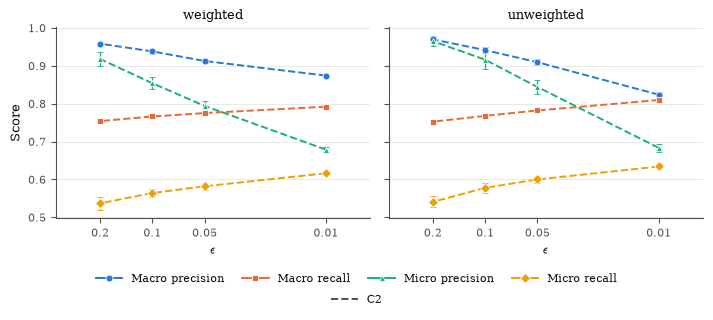

In [10]:
shown_configs = ["C2"]  # e.g. ["C1", "C3"] to leave C2 out; the file is tagged to match
quality_fig = quality_plot(by_eps, configs=shown_configs)
print(figure_latex(figure_path(shown_configs).removeprefix("../"),
                   r"Learned quality against $\epsilon$, weighted (left) and unweighted"
                   r" (right) sampling. The error bars are the 95\% $t$ interval over the"
                   r" seeds behind each point; the runs are those of"
                   r" Table~\ref{table:repeats-combined}. Only the unweighted arm was run"
                   r" at $\epsilon$=0.1.",
                   "fig:quality-vs-epsilon"))

In [11]:
repeats_precomp_tex = summary_latex(results, precomp=True, models=["mistral"])
show(repeats_precomp_tex)
print(repeats_precomp_tex)

NameError: name 'results' is not defined

## The epsilon arms

$\epsilon$ sets the PAC sample budget: 10,661 samples at 0.2, 21,322 at 0.1 and
213,449 at 0.01. Every configuration has its ten seeds at 0.2 and at 0.01 under both
samplers -- the C2 reruns, lost the first time to the shared query cache, landed on
2026-09-17. The 0.1 arm was run unweighted only, so the weighted panel of the figure
steps straight from 0.01 to 0.2.

In [ ]:
for epsilon, epsilon_results in sorted(by_eps.items()):
    for (config, model, sampler, precomp), runs in sorted(epsilon_results.items(), key=str):
        arm = "precomp" if precomp else "noprecomp"
        print(f"eps={epsilon:g} {config} {model} {sampler} {arm}: n={len(runs)}")

eps=0.01 C1 mistral unweighted noprecomp: n=10
eps=0.01 C1 mistral weighted noprecomp: n=10
eps=0.01 C2 mistral unweighted noprecomp: n=10
eps=0.01 C2 mistral weighted noprecomp: n=10
eps=0.01 C3 mistral unweighted noprecomp: n=10
eps=0.01 C3 mistral weighted noprecomp: n=10
eps=0.1 C1 mistral unweighted noprecomp: n=10
eps=0.1 C1 mistral weighted noprecomp: n=10
eps=0.1 C2 mistral unweighted noprecomp: n=10
eps=0.1 C2 mistral weighted noprecomp: n=10
eps=0.1 C3 mistral unweighted noprecomp: n=10
eps=0.1 C3 mistral weighted noprecomp: n=10
eps=0.2 C1 deepseek-r1-14b weighted precomp: n=0
eps=0.2 C1 deepseek-r1-32b weighted noprecomp: n=1
eps=0.2 C1 mistral unweighted noprecomp: n=10
eps=0.2 C1 mistral unweighted precomp: n=10
eps=0.2 C1 mistral weighted noprecomp: n=10
eps=0.2 C1 mistral weighted precomp: n=10
eps=0.2 C2 deepseek-r1-32b weighted noprecomp: n=1
eps=0.2 C2 mistral unweighted noprecomp: n=10
eps=0.2 C2 mistral unweighted precomp: n=10
eps=0.2 C2 mistral weighted noprecomp

## Precomputation

The LLM's precomputation against the reasoner's, which answers every class pair
correctly (`logs/baselines/reasoner-precomp.log`), with the empty T-box as the floor.

In [ ]:
precomputation_tex = precomputation_latex(results, models=["mistral"], empty=empty, reasoner=reasoner)
show(precomputation_tex)
print(precomputation_tex)

\begin{table*}[]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{@{}lrrrrr@{}}
\toprule
 &  & \multicolumn{4}{c}{\textbf{Quality}} \\
\cmidrule(lr){3-6}
 &  & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Macro}} & \multicolumn{1}{l}{\textbf{Micro}} & \multicolumn{1}{l@{}}{\textbf{Micro}} \\
\textbf{Evaluated on} & \textbf{Axioms} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l}{\textbf{Recall}} & \multicolumn{1}{l}{\textbf{Precision}} & \multicolumn{1}{l@{}}{\textbf{Recall}} \\
\midrule
\multicolumn{6}{@{}l}{\itshape Empty T-box (no learning)} \\
C1 & \multirow{3}{*}{0} & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l}{0.722} & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l@{}}{0.218} \\
C2 &  & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l}{0.721} & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l@{}}{0.434} \\
C3 &  & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l}{0.318} & \multicolumn{1}{l}{1.000} & \multicolumn{1}{l@{}}{0.206} \\
\addlinespace
\mul

In [ ]:
wrong, missed = precomp_disagreement(results, "mistral", reasoner)
print(f"{len(wrong)} added but not entailed, {len(missed)} entailed but not added")
for sub, sup in wrong:
    print(f"  wrong:  {sub} SubClassOf {sup}")
for sub, sup in missed:
    print(f"  missed: {sub} SubClassOf {sup}")

186 added but not entailed, 137 entailed but not added
  wrong:  AeronauticalEngineering SubClassOf CivilEngineering
  wrong:  AeronauticalEngineering SubClassOf Geosciences
  wrong:  AeronauticalEngineering SubClassOf MechanicalEngineering
  wrong:  Anthropology SubClassOf Faculty
  wrong:  Anthropology SubClassOf Humanities
  wrong:  Anthropology SubClassOf Science
  wrong:  Architecture SubClassOf ClericalStaff
  wrong:  Architecture SubClassOf Faculty
  wrong:  Architecture SubClassOf Humanities
  wrong:  Architecture SubClassOf HumanitiesAndSocialScience
  wrong:  AsianArts SubClassOf Humanities
  wrong:  AsianArts SubClassOf HumanitiesAndSocialScience
  wrong:  AsianArts SubClassOf PerformingArts
  wrong:  AssistantProfessor SubClassOf ClericalStaff
  wrong:  AssociateProfessor SubClassOf ClericalStaff
  wrong:  Astronomy SubClassOf Physics
  wrong:  Badminton SubClassOf Game
  wrong:  BasketBall SubClassOf Game
  wrong:  BiomedicalEngineering SubClassOf Science
  wrong:  Chemica

## Counterexample arrival rate

Whether counterexamples arrive more slowly later in a run. The gap is the samples
drawn since the previous one; each seed is one replicate, so the trend test is a
per-seed rank correlation with the counterexample index and a sign test over the
seeds. A run submitted on its own is one replicate, at n=1. Weighted arm only; pass
`sampler="unweighted"` to `arrival_latex` for the other one.

In [ ]:
CE_LINE = re.compile(r"Counterexample \d+ at sample (\d+) \(\+(\d+) since the last one\)")
BUDGET = re.compile(r"PAC sample budget \(numberOfSamples\) = (\d+)")

QUARTERS = 4


def arrivals(path):
    """-> (gaps between counterexamples, sample of the last one, budget)."""
    text = open(path, errors="replace").read()
    ces = [(int(s), int(g)) for s, g in CE_LINE.findall(text)]
    budget = BUDGET.search(text)
    return ([g for _, g in ces], ces[-1][0] if ces else 0,
            int(budget[1]) if budget else None)





In [ ]:
def arrival_cells(runs):
    """n, median CEs, mean gap per quarter pooled over seeds, Q4/Q1 and tail."""
    runs = [arrivals(r["path"]) for r in runs]
    runs = [(g, last, budget) for g, last, budget in runs if len(g) >= QUARTERS]
    if not runs:
        return None

    quarters = []
    for q in range(QUARTERS):
        pooled = [g[len(g) * q // QUARTERS:len(g) * (q + 1) // QUARTERS] for g, _, _ in runs]
        quarters.append(statistics.mean([x for chunk in pooled for x in chunk]))

    # Budget left unspent after the last counterexample: high means the run ran
    # out of things to learn long before it ran out of budget.
    tail = statistics.median([(b - last) / b for _, last, b in runs if b])
    ces = statistics.median([len(g) for g, _, _ in runs])
    return ([str(len(runs)), f"{ces:.0f}"] + [f"{q:.0f}" for q in quarters]
            + [f"{quarters[-1] / quarters[0]:.2f}", f"{tail * 100:.0f}\\%"])


ARRIVAL_HEADER = r""" &  &  & \multicolumn{4}{c}{\textbf{Mean gap}} & \multicolumn{2}{c}{\textbf{Trend}} \\
\cmidrule(lr){4-7} \cmidrule(lr){8-9}
\textbf{Config} & \textbf{n} & \textbf{CEs} & \textbf{Q1} & \textbf{Q2} & \textbf{Q3} & \textbf{Q4} & \textbf{Q4/Q1} & \textbf{tail} \\"""


def arrival_latex(results, sampler="weighted", precomp=False, models=None, configs=CONFIGS):
    """models: folder keys to show, in order; default every model with a folder.
    configs: the rows to show, C1-C3 by default."""
    blocks = [(MODELS.get(m, m),
               per_config(arrival_cells, runs_per_config(results, m, sampler, precomp, configs)))
              for m in models or models_in(results, sampler, precomp)]
    return table_latex(blocks, ARRIVAL_HEADER,
                       "Mean samples between counterexamples, by quarter of each run, "
                       "pooled over the replicates. Tail is the unspent budget. "
                       "A gap cannot exceed the budget left, biasing late quarters down.",
                       "table:arrivals", cols="l" + "r" * 8,  # n is a column here
                       configs=configs)


In [ ]:
arrival_tex = arrival_latex(results, models=["mistral"])
show(arrival_tex)